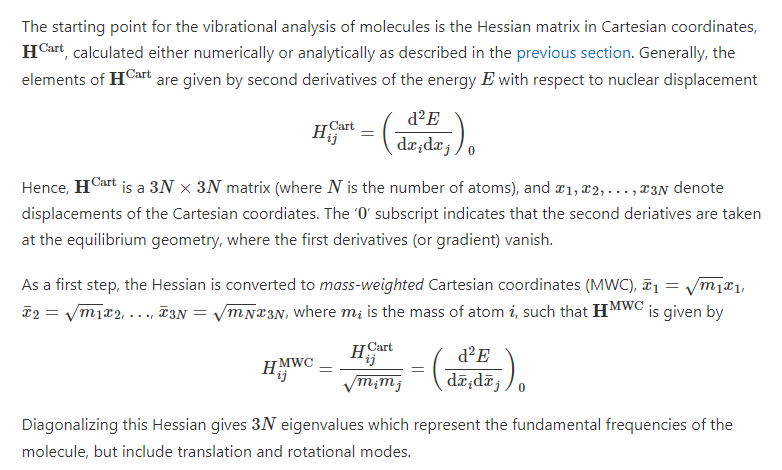

In [77]:
import veloxchem as vlx
import numpy as np
import sys
# import py3Dmol as p3d
from veloxchem.veloxchemlib import bohr_in_angstroms

# Define the molecule and basis set
molecule_string = """3

  O 0.000 0.000  0.000
  H 0.000 0.000  0.950
  H 0.896 0.000 -0.317"""
basis_set_label = 'sto-3g'

molecule = vlx.Molecule.from_xyz_string(molecule_string)
basis = vlx.MolecularBasis.read(molecule, basis_set_label)

# Run the SCF calculation
scf_settings = {}
method_settings = {} #{'xcfun':'b3lyp'}
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.update_settings(scf_settings, method_settings)
scf_results = scf_drv.compute(molecule, basis)

# Create the Hessian Driver and use it to compute an analytical SCF Hessian
hessian_settings = {}
hessian_drv = vlx.scfhessiandriver.ScfHessianDriver(scf_drv)
hessian_drv.update_settings(method_settings, hessian_settings)
hessian_drv.compute(molecule, basis)

hessian_drv.vibrational_analysis(molecule)

* Info * Reading basis set from file: /home/vlew/miniconda3/envs/vlxsthlm/lib/python3.9/site-packages/veloxchem/basis/STO-3G
                                                                                                                          
                                              Molecular Basis (Atomic Basis)                                              
                                                                                                                          
                               Basis: STO-3G                                                                              
                                                                                                                          
                               Atom Contracted GTOs           Primitive GTOs                                              
                                                                                                                          
              

In [83]:
masses = molecule.masses_to_numpy()

In [80]:
freqs,ints = hessian_drv.frequencies, hessian_drv.ir_intensities
nmodes = hessian_drv.normal_modes
print(freqs)
print(nmodes)

[1927.08373459 4545.77737601 4896.43870504]
[[-0.05871575 -0.         -0.04148966  0.70537519 -0.         -0.00915599  0.22660898  0.          0.6677136 ]
 [ 0.0397284  -0.          0.02738078  0.02992322  0.         -0.70002684 -0.66052473  0.          0.26541674]
 [-0.04155501  0.          0.05948154  0.00019765 -0.         -0.71105775  0.65939737 -0.         -0.23308169]]


In [27]:
help(hessian_drv)

Help on ScfHessianDriver in module veloxchem.scfhessiandriver object:

class ScfHessianDriver(veloxchem.hessiandriver.HessianDriver)
 |  ScfHessianDriver(scf_drv, comm=None, ostream=None)
 |  
 |  Implements SCF Hessian driver.
 |  
 |  :param scf_drv:
 |      The SCF driver.
 |  :param comm:
 |      The MPI communicator.
 |  :param ostream:
 |      The output stream.
 |  
 |  Instance variables
 |      - scf_drv: The SCF driver.
 |      - do_raman: Additionally calculate Raman intensities
 |              (at significantly higher computational cost).
 |  
 |  Method resolution order:
 |      ScfHessianDriver
 |      veloxchem.hessiandriver.HessianDriver
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, scf_drv, comm=None, ostream=None)
 |      Initializes SCF Hessian driver.
 |  
 |  compute(self, molecule, ao_basis, min_basis=None)
 |      Computes the analytical or numerical nuclear Hessian.
 |      
 |      :param molecule:
 |          The molecule.
 |  

In [96]:
np.set_printoptions(suppress=True, linewidth=150)

vlx_freqs, vlx_ints = hessian_drv.frequencies, hessian_drv.ir_intensities

hessian = hessian_drv.get_hessian()
print(vlx_freqs)
# print(y1)

print('\nHessian')
print(hessian)
print(hessian.shape)

[1927.08373459 4545.77737601 4896.43870504]

Hessian
[[ 0.7734178  -0.00000033 -0.22069612 -0.05793216  0.00000008  0.0591526  -0.71548565 -0.00000036  0.16154249]
 [-0.00000033 -0.08462406 -0.00000037  0.00000014  0.04250783 -0.00000029 -0.00000031  0.04211613  0.00000016]
 [-0.22069612 -0.00000037  0.93182659 -0.07097801 -0.00000044 -0.79549529  0.29167313  0.00000004 -0.13633129]
 [-0.05793216  0.00000014 -0.07097801  0.0535268   0.00000002 -0.01075585  0.00440529 -0.00000009  0.08173295]
 [ 0.00000008  0.04250783 -0.00000044  0.00000002 -0.02940301 -0.00000053 -0.00000002 -0.01310482  0.        ]
 [ 0.0591526  -0.00000029 -0.79549529 -0.01075585 -0.00000053  0.80288073 -0.04839783 -0.00000001 -0.00738545]
 [-0.71548565 -0.00000031  0.29167313  0.00440529 -0.00000002 -0.04839783  0.71108039 -0.00000039 -0.24327537]
 [-0.00000036  0.04211613  0.00000004 -0.00000009 -0.01310482 -0.00000001 -0.00000039 -0.02901139 -0.00000013]
 [ 0.16154249  0.00000016 -0.13633129  0.08173295  0.      

In [102]:

# masses = []
import math
nrows, ncols = hessian.shape

hessian_mass_weighted = hessian.copy() # mass-weighted hessian from vlx

for i in range(nrows):
    for j in range(ncols):
        _denom = math.sqrt(masses[i // 3] * masses[j // 3])
        hessian_mass_weighted[i, j] /= _denom

print('Mass-weighted Hessian')
print(hessian_mass_weighted)        # mass-weighted hessian from vlx
        
import scipy.linalg as spl
eigvals, eigvecs = spl.eig(hessian_mass_weighted)    # eigenvals and eigenvecs solved

bohr2m = 0.529177249e-10
hartree2joule = 4.35974434e-18
speed_of_light = 299792458
avogadro = 6.0221413e+23

vib_constant = math.sqrt((avogadro*hartree2joule*1000)/(bohr2m*bohr2m))/(2*math.pi*speed_of_light*100)
vibfreqs = np.sqrt(eigvals) * vib_constant       # freqs calculation based on eigenvals

print('\nEigenvectors')
# print(eigvals.real)
print(eigvecs)
print(eigvecs.shape)


print('\nFreqs from vlx')
print(vlx_freqs)
print('\nFreqs from eigenvals')
print(vibfreqs.real)
print(sorted(vibfreqs.real[:3]))
# print(vibfreqs.real)
print(vibfreqs.real.shape)

Mass-weighted Hessian
[[ 0.04835398 -0.00000002 -0.01379789 -0.014429    0.00000002  0.01473297 -0.17820398 -0.00000009  0.04023493]
 [-0.00000002 -0.00529069 -0.00000002  0.00000003  0.0105873  -0.00000007 -0.00000008  0.01048974  0.00000004]
 [-0.01379789 -0.00000002  0.05825768 -0.01767829 -0.00000011 -0.19813175  0.0726462   0.00000001 -0.03395565]
 [-0.014429    0.00000003 -0.01767829  0.05311121  0.00000002 -0.01067234  0.00437108 -0.00000009  0.08109835]
 [ 0.00000002  0.0105873  -0.00000011  0.00000002 -0.02917472 -0.00000052 -0.00000002 -0.01300307  0.        ]
 [ 0.01473297 -0.00000007 -0.19813175 -0.01067234 -0.00000052  0.79664697 -0.04802206 -0.00000001 -0.00732811]
 [-0.17820398 -0.00000008  0.0726462   0.00437108 -0.00000002 -0.04802206  0.70555939 -0.00000039 -0.24138652]
 [-0.00000009  0.01048974  0.00000001 -0.00000009 -0.01300307 -0.00000001 -0.00000039 -0.02878614 -0.00000013]
 [ 0.04023493  0.00000004 -0.03395565  0.08109835  0.         -0.00732811 -0.24138652 -0.0

In [31]:
help(hessian_drv)

Help on ScfHessianDriver in module veloxchem.scfhessiandriver object:

class ScfHessianDriver(veloxchem.hessiandriver.HessianDriver)
 |  ScfHessianDriver(scf_drv, comm=None, ostream=None)
 |  
 |  Implements SCF Hessian driver.
 |  
 |  :param scf_drv:
 |      The SCF driver.
 |  :param comm:
 |      The MPI communicator.
 |  :param ostream:
 |      The output stream.
 |  
 |  Instance variables
 |      - scf_drv: The SCF driver.
 |      - do_raman: Additionally calculate Raman intensities
 |              (at significantly higher computational cost).
 |  
 |  Method resolution order:
 |      ScfHessianDriver
 |      veloxchem.hessiandriver.HessianDriver
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, scf_drv, comm=None, ostream=None)
 |      Initializes SCF Hessian driver.
 |  
 |  compute(self, molecule, ao_basis, min_basis=None)
 |      Computes the analytical or numerical nuclear Hessian.
 |      
 |      :param molecule:
 |          The molecule.
 |  

In [42]:
Q = hessian_drv.normal_modes.T
Q

array([[-0.05871574,  0.03972842, -0.041555  ],
       [-0.        , -0.        ,  0.        ],
       [-0.04148964,  0.02738078,  0.05948155],
       [ 0.70537519,  0.02992306,  0.0001976 ],
       [-0.        ,  0.        , -0.        ],
       [-0.00915622, -0.7000267 , -0.71105791],
       [ 0.22660888, -0.66052493,  0.6593972 ],
       [ 0.        ,  0.        , -0.        ],
       [ 0.66771363,  0.26541664, -0.23308169]])

In [106]:
dipole_drv = vlx.ElectricDipoleIntegralsDriver()
dipole_mats = dipole_drv.compute(molecule, basis)
mu_x = dipole_mats.x_to_numpy()
mu_y = dipole_mats.y_to_numpy()
mu_z = dipole_mats.z_to_numpy()
print(mu_x)
print(mu_y)
print(mu_z.shape)

[[ 0.          0.          0.          0.00377458  0.          0.          0.05079193]
 [ 0.          0.          0.          0.34658158  0.          0.          0.64117286]
 [ 0.          0.          0.          0.20174404  0.          0.          0.30815434]
 [ 0.00377458  0.34658158  0.20174404  1.69319461  0.         -0.09796042  0.5848613 ]
 [ 0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.         -0.09796042  0.          0.          0.        ]
 [ 0.05079193  0.64117286  0.30815434  0.5848613   0.          0.          0.        ]]
[[0.         0.         0.         0.         0.05079193 0.         0.        ]
 [0.         0.         0.         0.         0.64117286 0.         0.        ]
 [0.         0.         0.         0.         0.30815434 0.         0.        ]
 [0.         0.         0.         0.         0.30797634 0.         0.        ]
 [0.05079193 0.64117286 0.30815434 0.30797634 0.         0.         0.

In [47]:
natoms = 3
def atomic_property(Omega, D):
    
    Omega_AB = np.zeros((natoms, natoms))

    Omega_L = np.einsum('ba,bc,cd->ad', T, Omega, T)
    D_L = np.einsum('ab,bc,dc->ad', inv(T), D, inv(T))
    
    idx_A = 0
    for A in range(natoms):

        idx_B = 0
        for B in range(natoms):
            
            P = Omega_L[idx_A : idx_A + norb_per_atom[A], idx_B : idx_B + norb_per_atom[B]]
            Q = D_L[idx_A : idx_A + norb_per_atom[A], idx_B : idx_B + norb_per_atom[B]]
        
            Omega_AB[A,B] = np.matmul(P.T, Q).trace()
                    
            idx_B += norb_per_atom[B]
            
        idx_A += norb_per_atom[A]
        
    return Omega_AB

S = scf_drv.scf_tensors['S']

# atomic numbers and therefore nuclear charge in atomic units
Z_A = molecule.elem_ids_to_numpy()
D = 2 * scf_drv.scf_tensors['D_alpha']

Q_A = - atomic_property(S, D).sum(axis = 1)
Q = Q_A.sum()

print(f"Total electronic charge: {Q : .4f}")
print(f"Localized atomic charges: {Q_A + Z_A}")


dipole_drv = vlx.ElectricDipoleIntegralsDriver()
dipole_mats = dipole_drv.compute(molecule, basis)

mu = - dipole_mats.z_to_numpy()

mu_AB = atomic_property(mu, D)

print(f'Total dipole moment: {mu_AB.sum() : .4f}')
print('\nmu_AB:\n', mu_AB)

NameError: name 'T' is not defined

In [104]:
print(hessian_drv.normal_modes[0].reshape(3, 3))
hessian_drv.normal_modes[0]

[[-0.05871575 -0.         -0.04148966]
 [ 0.70537519 -0.         -0.00915599]
 [ 0.22660898  0.          0.6677136 ]]


array([-0.05871575, -0.        , -0.04148966,  0.70537519, -0.        , -0.00915599,  0.22660898,  0.        ,  0.6677136 ])

In [36]:
coords = molecule.get_coordinates() * bohr_in_angstroms()
coords

array([[ 0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.95 ],
       [ 0.896,  0.   , -0.317]])

In [25]:
# To animate the normal mode we will need both the geometry and the displacements 
def get_normal_mode(molecule, normal_mode):
    elements = molecule.get_labels()
    # Transform from au to A
    coords = molecule.get_coordinates() * bohr_in_angstroms()
    natm = molecule.number_of_atoms()
    
    vib_xyz = "%d\n\n" % natm
    # print()
    nm = normal_mode.reshape(natm, 3)
    for i in range(natm):
        # add coordinates:
        vib_xyz += elements[i] + " %15.7f %15.7f %15.7f " % (coords[i,0], coords[i,1], coords[i,2])
        # add displacements:
        vib_xyz += "%15.7f %15.7f %15.7f\n" % (nm[i,0], nm[i,1], nm[i,2])
    return vib_xyz

vib_1 = get_normal_mode(molecule, hessian_drv.normal_modes[0])
vib_2 = get_normal_mode(molecule, hessian_drv.normal_modes[1])
vib_3 = get_normal_mode(molecule, hessian_drv.normal_modes[2])
print(vib_1)
print(vib_2)

3

O       0.0000000       0.0000000       0.0000000      -0.0587157      -0.0000000      -0.0414896
H       0.0000000       0.0000000       0.9500000       0.7053752      -0.0000000      -0.0091562
H       0.8960000       0.0000000      -0.3170000       0.2266089       0.0000000       0.6677136

3

O       0.0000000       0.0000000       0.0000000       0.0397284      -0.0000000       0.0273808
H       0.0000000       0.0000000       0.9500000       0.0299231       0.0000000      -0.7000267
H       0.8960000       0.0000000      -0.3170000      -0.6605249       0.0000000       0.2654166



In [32]:
hessian_drv.vibrational_analysis(molecule)

                                              Molecular Geometry (Angstroms)                                              
                                                                                                                          
                          Atom         Coordinate X          Coordinate Y          Coordinate Z                           
                                                                                                                          
                           O           0.000000000000        0.000000000000        0.000000000000                         
                           H           0.000000000000        0.000000000000        0.950000000000                         
                           H           0.896000000000        0.000000000000       -0.317000000000                         
                                                                                                                          
                